# Explore: run the GA yourself

A hands-on tour of the framework on **one kangaroo**: pick settings, run the GA, score the result with the course grader, and look at it. Select the **Python (ps1)** kernel and run the cells top to bottom; each takes seconds.

Results are saved under `runs/explore/` (git-ignored). Don't save exploration results into `submissions/`: CI checks every file there against the full submission requirements, and a one-kangaroo file would fail them.

In [ ]:
# Setup: work from the repo root so `linkopt` and `LINKS` import.

# Re-read changed linkopt/*.py files before every cell (like MATLAB does), so edits
# to the code show up without restarting the kernel. If something still acts stale,
# restart the kernel (toolbar ↻) and Run All.
%load_ext autoreload
%autoreload 2

import os
from pathlib import Path

root = Path.cwd()
while not (root / 'linkopt').is_dir() and root != root.parent:
    root = root.parent
os.chdir(root)

import linkopt  # always import first: pins JAX to the CPU
import numpy as np
import matplotlib.pyplot as plt

print('working in', root)

## 1. Choose settings

Start from a preset and override anything (see the README's *Choosing settings* table). `quick` is a real but short run. Try changing `n_gen`, `pop_size` or `mutation_prob`.

In [23]:
from linkopt.config import preset

cfg = preset('quick')          # e.g. preset('quick', n_gen=60, pop_size=100)
cfg

Config(targets=(0, 1, 2), n_joints=(7,), seeds=(0,), n_start=50, pop_size=50, n_gen=30, mutation_prob=None, grad_steps=200, step_size=0.0004, n_workers=3)

## 2. Run the GA on one kangaroo

- `target`: `0` = Kangaroo 1 (easiest), `1` = Kangaroo 2, `2` = Kangaroo 3 (loosest limits)
- `n_joints`: mechanism size (5 to 20)
- `seed`: different seeds give different random starting mechanisms and a different run. Results vary a lot between seeds; that's normal for a GA.

`result.designs` are the feasible non-dominated designs (inside both limits, and no other design is better at both). `result.F` holds each one's `[distance, material]`.

In [24]:
from linkopt.ga import run_ga

TARGET = 1
result = run_ga(target=TARGET, n_joints=7, seed=0, cfg=cfg)

print(f'{len(result.designs)} designs, {result.n_evals} evaluations, {result.seconds:.1f}s')
print('best starting distance:', result.start_F[:, 0].min().round(3))
result.F  # [distance, material] per design

1 designs, 1500 evaluations, 2.9s
best starting distance: 1.456


array([[1.19832492, 9.18800926]])

## 3. Score it with the course grader

`build_submission` puts the designs under `'Problem {TARGET + 1}'`; `save` checks the starter notebook's format, writes the file, and scores it with `evaluate_submission`. Only this kangaroo scores; the other two are empty (0).

In [25]:
from linkopt.submission import build_submission, save

scores = save(build_submission({TARGET: result.designs}), f'runs/explore/kangaroo{TARGET + 1}.npy')
scores

{'Overall Score': 0.00030225565838513534,
 'Score Breakdown': {'Problem 1': 0.0,
  'Problem 2': 0.001360150462733109,
  'Problem 3': 0.0},
 'Normalized Score Breakdown': {'Problem 1': 0.0,
  'Problem 2': 0.000906766975155406,
  'Problem 3': 0.0}}

## 4. The trade-off: distance vs. material

Each blue point is a submitted design; the red point is the limits corner (the reference point). The shaded area is the hypervolume, the score. Two views of the same result:

- **Left, zoomed (the course's plot):** fits the axes to the points, so you can see the shape of the front and how the designs trade distance for material. It can make a tiny area look large.
- **Right, full box:** the axes start at **(0, 0), the utopia point** (a perfect fit with no material), so the shaded area shows its true share of the scoring box. Designs further toward the bottom-left cover more of it.

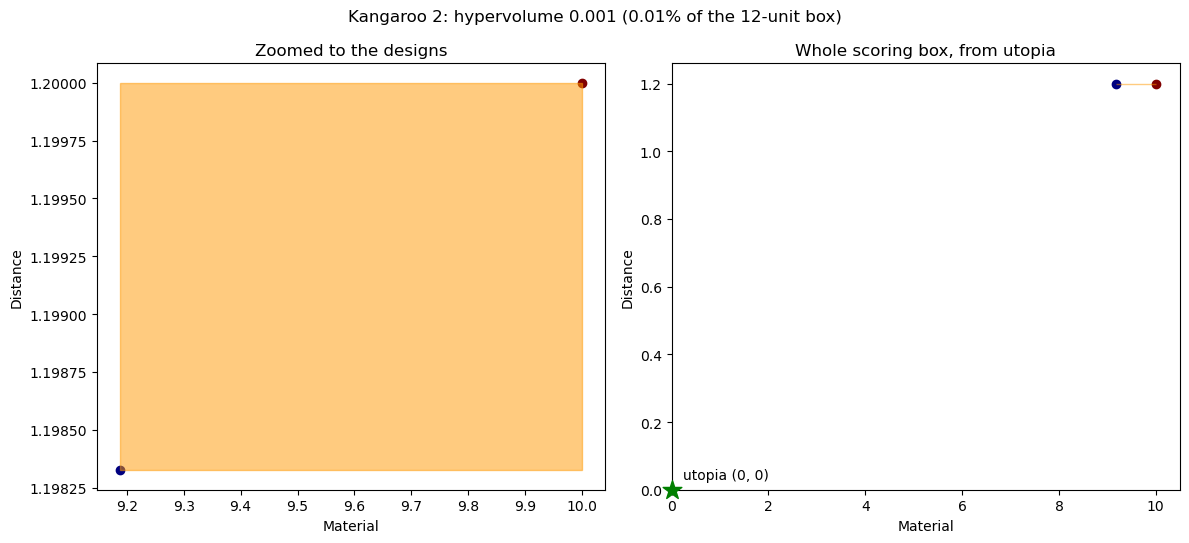

In [ ]:
from pymoo.indicators.hv import HV

from LINKS.CP import REFERENCE_POINTS
from LINKS.Visualization import GAVisualizer

ref = REFERENCE_POINTS[TARGET]  # (distance limit, material limit)
if len(result.F):
    hv = HV(ref)(result.F)
    box = ref[0] * ref[1]
    fig, (zoomed, full) = plt.subplots(1, 2, figsize=(12, 5.5))
    fig.suptitle(f'Kangaroo {TARGET + 1}: hypervolume {hv:.3f} ({hv / box:.2%} of the {box:.0f}-unit box)')

    # Left: the course's plot as-is (axes zoomed to fit the points).
    GAVisualizer().plot_HV(result.F, ref, objective_labels=['Distance', 'Material'], ax=zoomed)
    zoomed.set_title('Zoomed to the designs')

    # Right: the same plot over the whole scoring box, from the utopia point (0, 0)
    # to the limits (material is on the x-axis, distance on the y-axis).
    GAVisualizer().plot_HV(result.F, ref, objective_labels=['Distance', 'Material'], ax=full)
    full.set_xlim(0, ref[1] * 1.05)
    full.set_ylim(0, ref[0] * 1.05)
    full.scatter(0, 0, marker='*', s=200, color='green', zorder=3, clip_on=False)
    full.annotate('Utopia (0, 0)', (0, 0), xytext=(8, 8), textcoords='offset points')
    full.set_title('Whole scoring box, from Utopia')

    plt.tight_layout()
    plt.show()
else:
    print('no feasible designs: try another seed, more generations, or TARGET = 2')

## 5. The closest-fitting mechanism

The submission is **all** the designs above, and the grader scores the whole set by hypervolume. It just picks **one design to look at**, the one with the smallest distance score (the closest fit by the grader's own measure), and draws it.

When the motor turns, every moving joint traces its own path, but only **one** joint's path is compared to the kangaroo: the design's `target_joint`, which the GA chose as part of the design.

- **First plot, the mechanism:** links in grey, fixed joints hatched, the motor link yellow. The **solid orange curve** is the target joint's path (the one that's scored). The **dashed blue curves** are the other joints' paths, shown for context and not scored.
- **Second plot, the fit:** only the target joint's path, overlaid on the kangaroo outline. The grader first shifts and rotates the path for the best match (without resizing it); the distance score measures the mismatch that's left. This is exactly what gets scored.

design 0: distance 1.198, material 9.188, scored joint 6


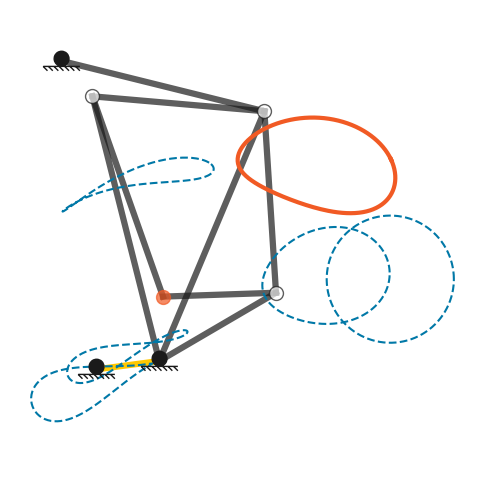

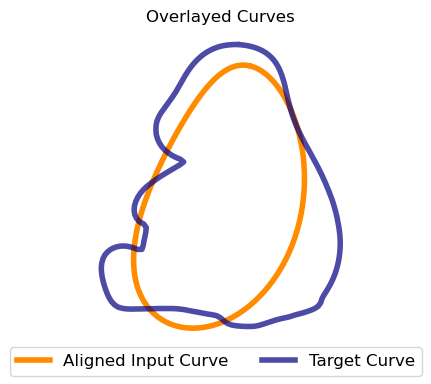

In [27]:
from linkopt.ga import target_curve
from LINKS.Geometry import CurveEngine
from LINKS.Kinematics import MechanismSolver
from LINKS.Visualization import MechanismVisualizer

if not result.designs:
    print('no feasible designs to show: try another seed, more generations, or TARGET = 2')
else:
    # Pick ONE design to look at. result.F[:, 0] is every design's distance score
    # (column 1 is material), so argmin gives the position of the closest fit.
    # To look at a different design instead:
    #   i = np.argmin(result.F[:, 1])   # the lowest-material design
    #   i = 2                           # or any design by position
    i = np.argmin(result.F[:, 0])
    best = result.designs[i]
    print(f'design {i}: distance {result.F[i, 0]:.3f}, material {result.F[i, 1]:.3f}, '
          f'scored joint {best["target_joint"]}')

    # Plot 1: the mechanism. highlight= marks the scored (target) joint; its path is
    # the solid orange curve. Dashed curves are the other joints' paths (not scored).
    plt.figure(figsize=(6, 6))
    MechanismVisualizer()(best['x0'], best['edges'], best['fixed_joints'], best['motor'],
                          highlight=best['target_joint'], ax=plt.gca())
    plt.show()

    # Plot 2: what the grader scores. Simulate one full motor turn: `paths` holds every
    # joint's path, shape (joints, 200 time steps, 2). Take only the target joint's path
    # and overlay it on the kangaroo, after the grader's best shift + rotation (no resizing).
    paths = MechanismSolver(device='cpu')(best['x0'], best['edges'], best['fixed_joints'], best['motor'])
    scored_path = paths[best['target_joint']]
    CurveEngine(device='cpu').visualize_comparison(scored_path, target_curve(TARGET))

## 6. Refine the GA's designs

The GA is good at big jumps (trying structures) but bad at fine-tuning, because its changes are random. `refine` walks each design **downhill**: the course's `DifferentiableTools` gives, for every joint, the direction to move it that reduces distance fastest (the *gradient*), and we take many small steps that way (up to `cfg.grad_steps` steps, trying each size in `cfg.step_sizes` and keeping each design's best).

- Only joint **positions** move; links, fixed joints, motor and target joint stay as the GA left them.
- A design that would leave the limits stops. Each design comes back at the **best position it reached**, so it's never worse than the GA's version.
- We submit **both** versions (the refined one can use more material), which can only add hypervolume.

The printout shows each design before → after; the plot shows each move as an arrow (usually downward: lower distance). With a single non-dominated design, the shaded area is a plain rectangle from that design to the limits corner; with several, it's a staircase.

In [ ]:
from pymoo.indicators.hv import HV

from linkopt.refine import refine
from LINKS.CP import REFERENCE_POINTS
from LINKS.Visualization import GAVisualizer

ref = REFERENCE_POINTS[TARGET]
if not result.designs:
    print('no feasible designs to refine: try another seed, more generations, or TARGET = 2')
else:
    # Fine-tune every design's joint positions with gradients (its structure is unchanged).
    # Each design comes back at the best position it reached: never a worse distance.
    refined = refine(result.designs, TARGET, cfg)
    for i, ((d0, m0), (d1, m1)) in enumerate(zip(refined.F_before, refined.F_after)):
        print(f'design {i}: distance {d0:.3f} -> {d1:.3f}, material {m0:.3f} -> {m1:.3f} '
              f'(best at step {refined.steps[i]})')

    # Keep BOTH versions: the GA's originals plus every refined design that changed.
    both = result.designs + refined.moved()
    F_both = np.vstack([refined.F_before, refined.F_after[refined.steps > 0]])
    print(f'hypervolume: {HV(ref)(refined.F_before):.3f} (GA only) -> {HV(ref)(F_both):.3f} (both)')

    # Plot: each design before (blue) and after refining (orange), an arrow for each move.
    fig, ax = plt.subplots(figsize=(6, 5.5))
    GAVisualizer().plot_HV(F_both, ref, objective_labels=['Distance', 'Material'], ax=ax)
    for (d0, m0), (d1, m1) in zip(refined.F_before, refined.F_after):
        ax.annotate('', xy=(m1, d1), xytext=(m0, d0),
                    arrowprops=dict(arrowstyle='->', color='darkorange'))
    ax.scatter(refined.F_after[:, 1], refined.F_after[:, 0], color='darkorange', zorder=3,
               label='refined')
    ax.set_title(f'Kangaroo {TARGET + 1}: GA designs and their refined versions')
    ax.legend()
    plt.show()

    scores = save(build_submission({TARGET: both}), f'runs/explore/kangaroo{TARGET + 1}_refined.npy')
    print('grader:', scores['Score Breakdown'][f'Problem {TARGET + 1}'])

## 7. More seeds, more designs

Each seed is an independent run. Pooling their designs usually raises the hypervolume: this is what `run.py` will do at scale, across all three kangaroos.

In [28]:
from pymoo.indicators.hv import HV

pooled, F = [], []
for seed in range(3):
    r = run_ga(target=TARGET, n_joints=7, seed=seed, cfg=cfg)
    pooled += r.designs
    F += list(r.F)
    own = HV(REFERENCE_POINTS[TARGET])(r.F) if len(r.F) else 0.0
    print(f'seed {seed}: {len(r.designs)} designs, own hypervolume {own:.3f}')

scores = save(build_submission({TARGET: pooled}), f'runs/explore/kangaroo{TARGET + 1}_pooled.npy')
print('pooled:', scores['Score Breakdown'][f'Problem {TARGET + 1}'])

seed 0: 1 designs, own hypervolume 0.001
seed 1: 1 designs, own hypervolume 0.574
seed 2: 0 designs, own hypervolume 0.000
pooled: 0.573558680800147


## Things to try

- `TARGET = 2` (Kangaroo 3) finds feasible designs most easily; `TARGET = 0` is the strictest.
- Bigger mechanisms: `n_joints=9` or `12`. More links can trace more complex shapes.
- Longer runs: `preset('quick', n_gen=100, pop_size=100)`.
- Mutation: `preset('quick', mutation_prob=0.3)` vs `0.9`.

 From Advanced notebook hints:
- Why not do some preprocessing to random mechanisms before running GA?
- Can you use the gradients of both functions in gradient based optimization?
- Can you cycle through multiple optimization runs?
- Can you mix different kinds of GA? We showed how GA can be used for a single mechanism skeleton and how it can be used to also create the mechanisms?
- Can you modify the GA mutations and cross-over?
- Is there a more efficient representation of mechanisms we can use?
- Are there smarter gradient-based optimization methods?

Anything worth keeping moves into `linkopt/` so `run.py` and CI use it.